# House Price Prediction using Linear Regression

**Task:** Regression  
**Model:** Linear Regression

### Problem statement
Predict house prices using area, number of bedrooms, number of bathrooms, age of the house, and location.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

## 1. Dataset

No dataset was supplied with the problem statement, so a small synthetic dataset is used for this experiment. The data contains the features mentioned in the question.

In [2]:
n = 1000

area = np.random.normal(1500, 450, n).clip(400, 3500)
bedrooms = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 4, n)
age = np.random.randint(0, 50, n)
location = np.random.choice(
    ["Downtown", "Suburb", "Rural"],
    size=n,
    p=[0.3, 0.5, 0.2]
)

# Location contributes a fixed amount to the price.
location_effect = {
    "Downtown": 50000,
    "Suburb": 20000,
    "Rural": 0
}

price = (
    120 * area
    + 15000 * bedrooms
    + 10000 * bathrooms
    - 800 * age
    + np.array([location_effect[x] for x in location])
    + np.random.normal(0, 20000, n)
)

df = pd.DataFrame({
    "area": area.round(1),
    "bedrooms": bedrooms,
    "bathrooms": bathrooms,
    "age": age,
    "location": location,
    "price": price.round(0)
})

df.head()

,area,bedrooms,bathrooms,age,location,price
0,1723.5,4,3,32,Downtown,323430.0
1,1437.8,1,3,49,Suburb,208482.0
2,1791.5,3,1,37,Suburb,242057.0
3,2185.4,5,3,26,Suburb,389130.0
4,1394.6,3,3,33,Downtown,238079.0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area       1000 non-null   float64
 1   bedrooms   1000 non-null   int64  
 2   bathrooms  1000 non-null   int64  
 3   age        1000 non-null   int64  
 4   location   1000 non-null   object 
 5   price      1000 non-null   float64
dtypes: float64(2), int64(3), object(1)
memory usage: 47.0+ KB


,area,bedrooms,bathrooms,age,price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1509.356000,3.045000,1.985000,24.583000,252019.402000
std,438.812318,1.424431,0.835148,14.630077,64060.308763
min,400.000000,1.000000,1.000000,0.000000,33094.000000
25%,1208.550000,2.000000,1.000000,12.000000,205745.250000
50%,1511.350000,3.000000,2.000000,25.000000,251950.500000
75%,1791.600000,4.000000,3.000000,37.000000,293609.000000
max,3233.700000,5.000000,3.000000,49.000000,438578.000000


## 2. Exploratory Data Analysis

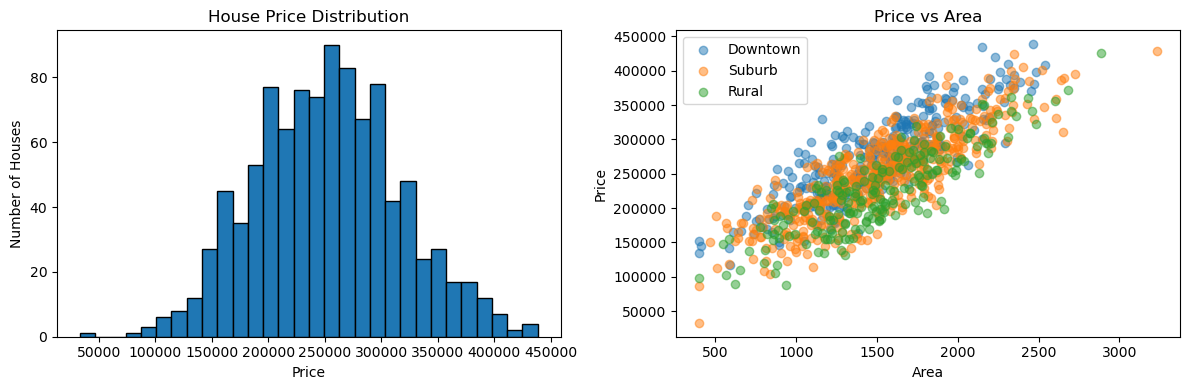

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["price"], bins=30, edgecolor="black")
axes[0].set_title("House Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of Houses")

for loc in ["Downtown", "Suburb", "Rural"]:
    part = df[df["location"] == loc]
    axes[1].scatter(part["area"], part["price"], alpha=0.5, label=loc)

axes[1].set_title("Price vs Area")
axes[1].set_xlabel("Area")
axes[1].set_ylabel("Price")
axes[1].legend()

plt.tight_layout()
plt.show()

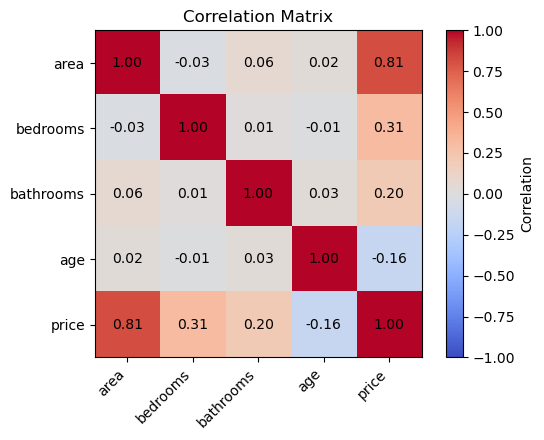

In [5]:
numeric_cols = ["area", "bedrooms", "bathrooms", "age", "price"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 4.5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

**Observation:** Area has a positive relationship with price, while age has a negative relationship. Location also changes the general price level.

## 3. Preprocessing

`location` is categorical, so it is converted into numerical columns using one-hot encoding.

In [6]:
df_encoded = pd.get_dummies(df, columns=["location"], drop_first=True, dtype=int)

X = df_encoded.drop(columns="price")
y = df_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


## 4. Linear Regression

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,area,118.878806
1,bedrooms,15212.677201
2,bathrooms,10630.723707
3,age,-863.484979
4,location_Rural,-49769.478724
5,location_Suburb,-29890.942119


In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 15,437.14
RMSE : 19,394.10
R²   : 0.9045


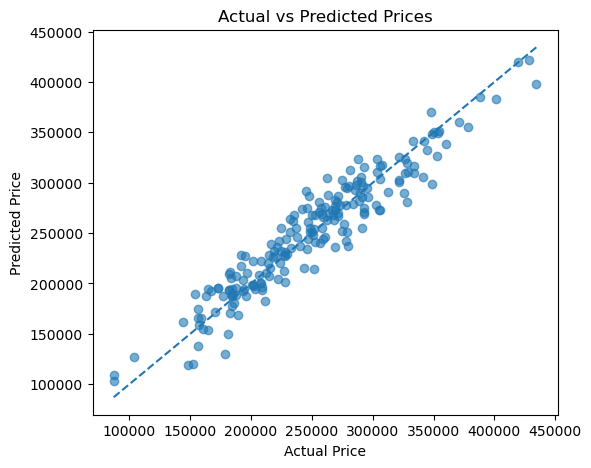

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

## 5. Conclusion

Linear Regression was used to predict house prices from area, bedrooms, bathrooms, age and location. The categorical location feature was converted using one-hot encoding. MAE, RMSE and R² were used to evaluate the model on the test set. The actual-versus-predicted plot gives a visual comparison of the predictions.